In [1]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

# Verify the path was added (optional)
print(f"Project root added to sys.path: {project_root}")

Project root added to sys.path: /mnt/c/Users/LENOVO/sandbox/portfolio/geomarketing-coffeshop-makassar


In [2]:
import pandas as pd

from utils.utils import clean_text, lemmatize_tokens, extract_rating

/home/matimatech/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
reviews_cust = pd.read_csv('../dataset/reviews_Onkel John\'s Coffee Hasanuddin.csv')

In [4]:
reviews_cust.head()

,nama,reviews,rating
0,ekov_3,Awalnya penasaran deket hotel kuk ramai sekali...,5 bintang
1,Siba Waihi,"Kopi & snack nya enak, tersedia makanan berat,...",5 bintang
2,Alvia Fadliana,"Tempatnya sangat nyaman, tenang, relax.\nsy or...",5 bintang
3,Jasmir Aly,Sangat rekomended.\nDan pelayanannya sangat ba...,5 bintang
4,aisah ulfah Syam,Temptnya bagus makanan enak & ada live musikny...,5 bintang


In [5]:
reviews_cust.shape

(239, 3)

**Preprocess Reviews**

In [6]:
reviews_cust.isna().sum()

nama        0
reviews    80
rating      0
dtype: int64

In [7]:
reviews_cust[reviews_cust['reviews'].isna()]

,nama,reviews,rating
118,A M F G M,NaN,4 bintang
151,PIERE PINONTOAN,NaN,5 bintang
152,Adha priyatnadi,NaN,5 bintang
154,Ahya Ahmadan,NaN,5 bintang
155,Kiki Sumarlin,NaN,5 bintang
...,...,...,...
234,Suzy Kandani,NaN,3 bintang
235,Fida Sulystiani,NaN,5 bintang
236,ffajrin karim,NaN,5 bintang
237,haris bayu,NaN,5 bintang


In [8]:
reviews_cust.dropna(inplace=True)

In [9]:
reviews_cust.drop_duplicates(inplace=True, ignore_index=True)

In [10]:
reviews_cust.drop_duplicates(subset=['nama'], inplace=True)
reviews_cust[reviews_cust.duplicated(subset=['nama'])]

,nama,reviews,rating


In [11]:
reviews_cust['rating'] = reviews_cust['rating'].apply(lambda x: extract_rating(x))
reviews_cust['cleaned_reviews'] = reviews_cust['reviews'].apply(lambda x: clean_text(x))
reviews_cust['tokens'] = reviews_cust['cleaned_reviews'].apply(lambda x: x.split()) # tokenization
reviews_cust['lemmatized'] = reviews_cust['tokens'].apply(lambda x: lemmatize_tokens(x))

In [12]:
reviews_cust.head()

,nama,reviews,rating,cleaned_reviews,tokens,lemmatized
0,ekov_3,Awalnya penasaran deket hotel kuk ramai sekali...,5,penasaran deket hotel kuk ramai dimalam coba m...,"[penasaran, deket, hotel, kuk, ramai, dimalam,...",penasaran deket hotel kuk ramai malam coba mom...
1,Siba Waihi,"Kopi & snack nya enak, tersedia makanan berat,...",5,kopi snack enak tersedia makanan berat parkir ...,"[kopi, snack, enak, tersedia, makanan, berat, ...",kopi snack enak sedia makan berat parkir luas ...
2,Alvia Fadliana,"Tempatnya sangat nyaman, tenang, relax.\nsy or...",5,tempatnya nyaman tenang relax sy order pizza m...,"[tempatnya, nyaman, tenang, relax, sy, order, ...",tempat nyaman tenang relax sy order pizza masu...
3,Jasmir Aly,Sangat rekomended.\nDan pelayanannya sangat ba...,5,rekomended pelayanannya bagus santai,"[rekomended, pelayanannya, bagus, santai]",rekomended layan bagus santai
4,aisah ulfah Syam,Temptnya bagus makanan enak & ada live musikny...,5,temptnya bagus makanan enak live musiknya bagus,"[temptnya, bagus, makanan, enak, live, musikny...",temptnya bagus makan enak live musik bagus


In [13]:
pd.set_option('display.max_colwidth', None)

low_rating = reviews_cust[reviews_cust['rating'] < 2].iloc[:].get(["nama", "cleaned_reviews", "lemmatized"])

In [14]:
pd.set_option('display.max_colwidth', None)

high_rating = reviews_cust[reviews_cust['rating'] == 5].iloc[:].get(["nama", "cleaned_reviews", "lemmatized"])

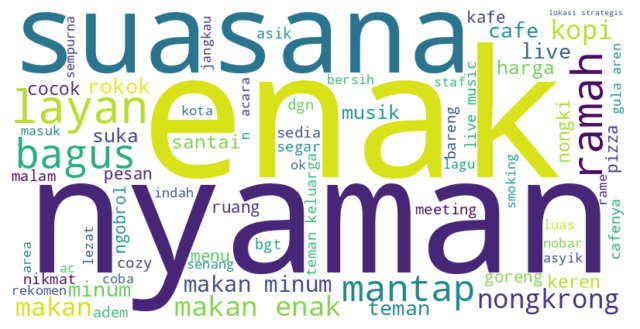

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword()

text = high_rating['lemmatized'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [18]:
pd.set_option('display.max_colwidth', None)

low_rating = reviews_cust[reviews_cust['rating'] < 3].iloc[:].get(["nama", "reviews", "cleaned_reviews", "lemmatized"])

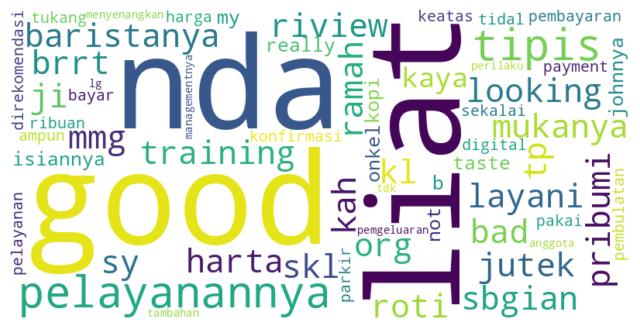

In [19]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword()

text = low_rating['cleaned_reviews'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [24]:
low_rating

,nama,reviews,cleaned_reviews,lemmatized
37,salma sisil,"baristanya sebagian mukanya jutek, mmg pribumi dia layani tp yg di liat good looking & good harta ji kl selain itu nda ramah skl, nda bisa di training itu kah pelayanannya? sy juga liat sbgian org2 riview tentang pelayanannya yg bad brrt di situ yg kurang.",baristanya mukanya jutek mmg pribumi layani tp liat good looking good harta ji kl nda ramah skl nda training kah pelayanannya sy liat sbgian org riview pelayanannya bad brrt,baristanya muka jutek mmg pribumi layan tp liat good looking good harta ji kl nda ramah skl nda training kah layan sy liat sbgian org riview layan bad brrt
58,eric tsu,"Roti kaya isiannya sedikit banget, tipis tipis gitu. Kopi onkel johnnya B aja sih, not really my taste.\nSaat pembayaran ada pembulatan (ribuan) harga keatas tanpa konfirmasi, meskipun bayar pakai digital payment.",roti kaya isiannya tipis tipis kopi onkel johnnya b not really my taste pembayaran pembulatan ribuan harga keatas konfirmasi bayar pakai digital payment,roti kaya isi tipis tipis kopi onkel johnnya b not really my taste bayar bulat ribu harga atas konfirmasi bayar pakai digital payment
62,Muh Alif,Pelayanan lama sekalai. Ampun ini tempat. Tidak direkomendasi,pelayanan sekalai ampun direkomendasi,layan sekala ampun rekomendasi
91,Ukka 46,Tidal usah ada tukang parkir. Pemgeluaran tambahan lg,tidal tukang parkir pemgeluaran tambahan lg,tidal tukang parkir pemgeluaran tambah lg
99,Herman Daeng Sijaya,Sangat tdk menyenangkan perilaku anggota managementnya,tdk menyenangkan perilaku anggota managementnya,tdk senang perilaku anggota managementnya


**insight**:
- Terdapat permasalahan di pelayanan barista seperti tidak ramah dan pelayanan yang lambat
- Terdapat tukang parkir yang menyebabkan terjadinya pengeluaran tambahan